# **365 Mens Clothing Store**

# **Phase II**

In [43]:
#Importing Libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import openpyxl as py
import datetime as dt


#Importing the dataset
orders_df = pd.read_excel('orders_data.xlsx')

##  **Data Quality Follow-Up**

#### Rows Lost To Joins 

In [44]:
# Find shipping records whose OrderID does not exist in the final orders table
shipping_df = pd.read_csv('Shipping.csv')

lost_shipping = shipping_df[
   ~shipping_df['OrderID'].isin(orders_df['OrderID'])
]

print("Shipping records in raw file:", len(shipping_df))
print("Shipping records lost to join:", len(lost_shipping))

print(
    "Shipping loss percentage:",
    round(len(lost_shipping) / len(shipping_df) * 100, 2),
    "%"
)


Shipping records in raw file: 654
Shipping records lost to join: 51
Shipping loss percentage: 7.8 %


In [45]:
lost_shipping

,OrderID,City,ShippingMethod
91,92.0,Coquitlam,Standard
98,99.0,Coquitlam,Nextday
194,195.0,Coquitlam,Standard
249,250.0,Coquitlam,Standard
253,254.0,Coquitlam,Nextday
254,255.0,Coquitlam,Standard
255,256.0,Coquitlam,Standard
260,261.0,Coquitlam,Nextday
262,263.0,Coquitlam,Standard
269,270.0,Coquitlam,Nextday


### 51 shipping records did not make it to the orders final data frame which is around 7.8% 
### All orders related to Coquitlam city did not make it to the orders data frame 

In [46]:
transactions_df = pd.read_csv('transactions.csv')
transaction_keys = ['OrderID', 'OrderLine']

lost_transactions = transactions_df[~transactions_df.set_index(transaction_keys).index.isin(orders_df.set_index(transaction_keys).index)]

print("Transaction lines in raw file:", len(transactions_df))
print("Transaction lines lost to join:", len(lost_transactions))

print(
    "Transaction loss percentage:",
    round(len(lost_transactions) / len(transactions_df) * 100, 2), "%")

Transaction lines in raw file: 661
Transaction lines lost to join: 51
Transaction loss percentage: 7.72 %


In [47]:
identify = lost_transactions['OrderID'].isin(lost_shipping['OrderID']).reset_index()
identify['OrderID'].value_counts()

OrderID
True    51
Name: count, dtype: int64

#### The same 51 records did not make it to the orders data frame and all of them are from the city of Coquitlam

#### Duplicate Transactions 

In [48]:
# 1. Capture the initial length of the raw dataset
total_raw_rows = len(transactions_df)

# 2. Find exact duplicate rows (every single column matches)
duplicates = transactions_df.duplicated(keep='first').sum()

# 4. Calculate the percentage of the raw file that was removed
pct_removed = (duplicates / total_raw_rows) * 100

print(f"Total Raw Rows: {total_raw_rows}")
print(f"Exact Duplicates Removed: {duplicates}")
print(f"Percentage of Rows Removed: {pct_removed:.2f}%")


# 5. Remove the duplicates for the final working dataframe
clean_transactions = transactions_df.drop_duplicates()

Total Raw Rows: 661
Exact Duplicates Removed: 7
Percentage of Rows Removed: 1.06%


#### Checking Duplicate Columns

In [49]:
t = transactions_df.duplicated(keep='first').reset_index()
t1 = t[t[0] == True]
transactions_df.iloc[t1.index]

,ProductID,Year,Month,Day,Quantity,OrderLine,OrderID
122,20,2019,11,7,4,122,122
123,20,2019,11,7,4,122,122
124,20,2019,11,7,4,122,122
125,20,2019,11,7,4,122,122
126,20,2019,11,7,4,122,122
127,20,2019,11,7,4,122,122
128,20,2019,11,7,4,122,122


#### Only 1.06% of the total rows have been removed
#### In my opinion this would not largely effect our analysis 

#### Missing Shipping Methods 

In [50]:
original_shipping_counts = shipping_df['ShippingMethod'].value_counts()
original_shipping_pct = shipping_df['ShippingMethod'].value_counts(normalize=True) * 100

print("Original Shipping Method Counts:\n", original_shipping_counts)
print("\nOriginal Shipping Method Percentages:\n", original_shipping_pct)

Original Shipping Method Counts:
 ShippingMethod
Standard     535
Expedited     55
Nextday       55
Name: count, dtype: int64

Original Shipping Method Percentages:
 ShippingMethod
Standard     82.945736
Expedited     8.527132
Nextday       8.527132
Name: proportion, dtype: float64


In [51]:
# Calculate the true distribution of shipping methods
shipping_counts = orders_df['ShippingMethod'].value_counts()
shipping_pct = orders_df['ShippingMethod'].value_counts(normalize=True) * 100

print("Shipping Method Counts:\n", shipping_counts)
print("\nShipping Method Percentages:\n", shipping_pct)

Shipping Method Counts:
 ShippingMethod
Standard     494
Expedited     59
Nextday       50
Name: count, dtype: int64

Shipping Method Percentages:
 ShippingMethod
Standard     81.923715
Expedited     9.784411
Nextday       8.291874
Name: proportion, dtype: float64


#### We only filled 4 values with Expedited from the original transactions data which is rougly around 1.26% 
#### In my opinion this would not have a huge effect on our analysis

## **Phase II: Anlysis & Requirements**

### Metric Development

In [52]:
# Gross Margin
orders_df['Gross_Margin'] = round((orders_df['Total Net Profit']/orders_df['Total Revenue']) * 100, 2)

# Revenure per unit
orders_df['Revenue_Per_Unit'] = orders_df['Total Revenue'] / orders_df['Quantity']

#Discount Value
orders_df['Discount_Value'] = (orders_df['Discount Pct'] / 100) * orders_df['Total Revenue']

# Create a 'Total' row by summing numerical columns
orders_df.loc['Total'] = orders_df.sum(numeric_only=True)

orders_df


,ProductID,Year,Month,Day,Quantity,OrderLine,OrderID,Name,Price,Cost,Type,Colour,City,ShippingMethod,StoreID,Date,Discount Pct,Sale Price,Net Profit,Total Revenue,Total Cost,Total Net Profit,Gross_Margin,Revenue_Per_Unit,Discount_Value
0,3.0,2019.0,1.0,2.0,2.0,1.0,1.0,"Sweater,White",30.0,10.0,Sweater,White,Vancouver,Standard,3.0,2019-01-02 00:00:00,0.0,30.0,20.0,60.0,20.0,40.0,66.67,30.0,0.0
1,8.0,2019.0,1.0,6.0,3.0,2.0,2.0,"T-shirt,Black",20.0,2.0,T-shirt,Black,Los Angeles,Expedited,5.0,2019-01-06 00:00:00,0.0,20.0,18.0,60.0,6.0,54.0,90.00,20.0,0.0
2,1.0,2019.0,1.0,6.0,1.0,3.0,3.0,"Sweater,Blue",30.0,10.0,Sweater,Blue,Burnaby,Standard,4.0,2019-01-06 00:00:00,0.0,30.0,20.0,30.0,10.0,20.0,66.67,30.0,0.0
3,8.0,2019.0,1.0,9.0,4.0,4.0,4.0,"T-shirt,Black",20.0,2.0,T-shirt,Black,Vancouver,Standard,3.0,2019-01-09 00:00:00,0.0,20.0,18.0,80.0,8.0,72.0,90.00,20.0,0.0
4,1.0,2019.0,1.0,12.0,2.0,5.0,5.0,"Sweater,Blue",30.0,10.0,Sweater,Blue,Los Angeles,Standard,5.0,2019-01-12 00:00:00,0.0,30.0,20.0,60.0,20.0,40.0,66.67,30.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
599,5.0,2022.0,7.0,31.0,3.0,651.0,651.0,"Hoodie,White",35.0,15.0,Hoodie,White,Langley,Standard,2.0,2022-07-31 00:00:00,0.0,35.0,20.0,105.0,45.0,60.0,57.14,35.0,0.0
600,7.0,2022.0,9.0,3.0,1.0,652.0,652.0,"T-shirt,White",15.0,2.0,T-shirt,White,Langley,Standard,2.0,2022-09-03 00:00:00,0.0,15.0,13.0,15.0,2.0,13.0,86.67,15.0,0.0
601,7.0,2022.0,10.0,29.0,2.0,653.0,653.0,"T-shirt,White",15.0,2.0,T-shirt,White,Langley,Standard,2.0,2022-10-29 00:00:00,0.0,15.0,13.0,30.0,4.0,26.0,86.67,15.0,0.0
602,7.0,2022.0,12.0,3.0,1.0,654.0,654.0,"T-shirt,White",15.0,2.0,T-shirt,White,Langley,Standard,2.0,2022-12-03 00:00:00,0.0,15.0,13.0,15.0,2.0,13.0,86.67,15.0,0.0


In [53]:
## Dropping the Totals row from orders_df for further analysis
orders_df = orders_df.drop('Total', axis=0)

In [54]:
orders_df["Discount_Value"].sum()

np.float64(254.1)

#### A totals row is added at the end of the data frame where it can clearly be seen that the Total discount value is 254.1

### Day Of Week 

In [55]:
# Convert the 'Date' column to datetime format
orders_df['Date'] = pd.to_datetime(orders_df['Date'])

# Create a new column Day_of_Week that contains the day of the week for each date in the Date column
orders_df['Day_of_Week'] = orders_df['Date'].dt.day_name()

# Returns True for Weekend, False for Weekday
orders_df['Is_Weekend'] = orders_df['Date'].dt.dayofweek.isin([5, 6])

orders_df

,ProductID,Year,Month,Day,Quantity,OrderLine,OrderID,Name,Price,Cost,Type,Colour,City,ShippingMethod,StoreID,Date,Discount Pct,Sale Price,Net Profit,Total Revenue,Total Cost,Total Net Profit,Gross_Margin,Revenue_Per_Unit,Discount_Value,Day_of_Week,Is_Weekend
0,3.0,2019.0,1.0,2.0,2.0,1.0,1.0,"Sweater,White",30.0,10.0,Sweater,White,Vancouver,Standard,3.0,2019-01-02,0.0,30.0,20.0,60.0,20.0,40.0,66.67,30.0,0.0,Wednesday,False
1,8.0,2019.0,1.0,6.0,3.0,2.0,2.0,"T-shirt,Black",20.0,2.0,T-shirt,Black,Los Angeles,Expedited,5.0,2019-01-06,0.0,20.0,18.0,60.0,6.0,54.0,90.00,20.0,0.0,Sunday,True
2,1.0,2019.0,1.0,6.0,1.0,3.0,3.0,"Sweater,Blue",30.0,10.0,Sweater,Blue,Burnaby,Standard,4.0,2019-01-06,0.0,30.0,20.0,30.0,10.0,20.0,66.67,30.0,0.0,Sunday,True
3,8.0,2019.0,1.0,9.0,4.0,4.0,4.0,"T-shirt,Black",20.0,2.0,T-shirt,Black,Vancouver,Standard,3.0,2019-01-09,0.0,20.0,18.0,80.0,8.0,72.0,90.00,20.0,0.0,Wednesday,False
4,1.0,2019.0,1.0,12.0,2.0,5.0,5.0,"Sweater,Blue",30.0,10.0,Sweater,Blue,Los Angeles,Standard,5.0,2019-01-12,0.0,30.0,20.0,60.0,20.0,40.0,66.67,30.0,0.0,Saturday,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
598,13.0,2022.0,7.0,9.0,1.0,650.0,650.0,"Socks,Grey",10.0,1.0,Socks,Grey,Langley,Standard,2.0,2022-07-09,30.0,7.0,6.0,7.0,1.0,6.0,85.71,7.0,2.1,Saturday,True
599,5.0,2022.0,7.0,31.0,3.0,651.0,651.0,"Hoodie,White",35.0,15.0,Hoodie,White,Langley,Standard,2.0,2022-07-31,0.0,35.0,20.0,105.0,45.0,60.0,57.14,35.0,0.0,Sunday,True
600,7.0,2022.0,9.0,3.0,1.0,652.0,652.0,"T-shirt,White",15.0,2.0,T-shirt,White,Langley,Standard,2.0,2022-09-03,0.0,15.0,13.0,15.0,2.0,13.0,86.67,15.0,0.0,Saturday,True
601,7.0,2022.0,10.0,29.0,2.0,653.0,653.0,"T-shirt,White",15.0,2.0,T-shirt,White,Langley,Standard,2.0,2022-10-29,0.0,15.0,13.0,30.0,4.0,26.0,86.67,15.0,0.0,Saturday,True


### Year-Month Period Column 

In [56]:
# Combine Year and Month, then convert to a Monthly Period (YYYY-MM)

orders_df['Year_Month'] = pd.to_datetime(
    orders_df['Year'].astype(int).astype(str) + '-' + orders_df['Month'].astype(int).astype(str),
    format='%Y-%m'
).dt.to_period('M')

orders_df

,ProductID,Year,Month,Day,Quantity,OrderLine,OrderID,Name,Price,Cost,Type,Colour,City,ShippingMethod,StoreID,Date,Discount Pct,Sale Price,Net Profit,Total Revenue,Total Cost,Total Net Profit,Gross_Margin,Revenue_Per_Unit,Discount_Value,Day_of_Week,Is_Weekend,Year_Month
0,3.0,2019.0,1.0,2.0,2.0,1.0,1.0,"Sweater,White",30.0,10.0,Sweater,White,Vancouver,Standard,3.0,2019-01-02,0.0,30.0,20.0,60.0,20.0,40.0,66.67,30.0,0.0,Wednesday,False,2019-01
1,8.0,2019.0,1.0,6.0,3.0,2.0,2.0,"T-shirt,Black",20.0,2.0,T-shirt,Black,Los Angeles,Expedited,5.0,2019-01-06,0.0,20.0,18.0,60.0,6.0,54.0,90.00,20.0,0.0,Sunday,True,2019-01
2,1.0,2019.0,1.0,6.0,1.0,3.0,3.0,"Sweater,Blue",30.0,10.0,Sweater,Blue,Burnaby,Standard,4.0,2019-01-06,0.0,30.0,20.0,30.0,10.0,20.0,66.67,30.0,0.0,Sunday,True,2019-01
3,8.0,2019.0,1.0,9.0,4.0,4.0,4.0,"T-shirt,Black",20.0,2.0,T-shirt,Black,Vancouver,Standard,3.0,2019-01-09,0.0,20.0,18.0,80.0,8.0,72.0,90.00,20.0,0.0,Wednesday,False,2019-01
4,1.0,2019.0,1.0,12.0,2.0,5.0,5.0,"Sweater,Blue",30.0,10.0,Sweater,Blue,Los Angeles,Standard,5.0,2019-01-12,0.0,30.0,20.0,60.0,20.0,40.0,66.67,30.0,0.0,Saturday,True,2019-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
598,13.0,2022.0,7.0,9.0,1.0,650.0,650.0,"Socks,Grey",10.0,1.0,Socks,Grey,Langley,Standard,2.0,2022-07-09,30.0,7.0,6.0,7.0,1.0,6.0,85.71,7.0,2.1,Saturday,True,2022-07
599,5.0,2022.0,7.0,31.0,3.0,651.0,651.0,"Hoodie,White",35.0,15.0,Hoodie,White,Langley,Standard,2.0,2022-07-31,0.0,35.0,20.0,105.0,45.0,60.0,57.14,35.0,0.0,Sunday,True,2022-07
600,7.0,2022.0,9.0,3.0,1.0,652.0,652.0,"T-shirt,White",15.0,2.0,T-shirt,White,Langley,Standard,2.0,2022-09-03,0.0,15.0,13.0,15.0,2.0,13.0,86.67,15.0,0.0,Saturday,True,2022-09
601,7.0,2022.0,10.0,29.0,2.0,653.0,653.0,"T-shirt,White",15.0,2.0,T-shirt,White,Langley,Standard,2.0,2022-10-29,0.0,15.0,13.0,30.0,4.0,26.0,86.67,15.0,0.0,Saturday,True,2022-10


### Required Analysis

#### Profitability 

In [57]:
# Gross Margin by Type

orders_df.groupby('Type')['Gross_Margin'].mean().sort_values(ascending=False).reset_index()

,Type,Gross_Margin
0,Socks,88.098971
1,T-shirt,87.800480
2,Sweater,68.370000
3,Jacket,60.527536
4,Hoodie,58.687216


In [58]:
# Total Revenue and Total Net Profit by Type
product_type_revenue = orders_df.groupby('Type').agg(
    Total_Revenue=('Total Revenue', 'sum'),
    Total_Net_Profit=('Total Net Profit', 'sum'),
).sort_values(by='Total_Revenue', ascending=False).reset_index()
product_type_revenue['Gross_Margin'] = round((product_type_revenue['Total_Net_Profit'] / product_type_revenue['Total_Revenue']) * 100, 2)

product_type_revenue

,Type,Total_Revenue,Total_Net_Profit,Gross_Margin
0,T-shirt,13745.0,12103.0,88.05
1,Hoodie,11040.0,6495.0,58.83
2,Jacket,9740.0,5900.0,60.57
3,Sweater,9365.0,6415.0,68.50
4,Socks,1792.0,1596.0,89.06


1. Gross Profit Margin Ranking
* Rank 1 (Most Profitable): Socks — 88.10%

* Rank 2: T-shirt — 87.80%

* Rank 3: Sweater — 68.37%

* Rank 4: Jacket — 60.53%

* Rank 5 (Least Profitable): Hoodie — 58.69%

2. Comparison to Revenue Ranking

   The rankings DO NOT match:

* Hoodies rank #2 in Total Revenue ($11,040.00), but hold the lowest rank (#5) in Gross Margin % (58.69%).
* Socks hold the number 1 rank in Gross Margin % (88.10%), but rank last (#5) in Total Revenue ($1,792.00).
* Jackets rank #3 in Total Revenue ($9,740.00), but rank #4 in Gross Margin % (60.53%).
* Sweaters rank #4 in Total Revenue ($9,365.00), but rank #3 in Gross Margin % (68.37%).
* T-shirts are the only partial alignment, generating the highest Total Revenue (#1 at $13,745.00) while maintaining the second-highest Gross Margin % #2 at 87.80%.

3. High-Revenue, Low-Margin Products (Hoodies)
* Hoodies generate high total revenue because their higher price tag brings in more absolute dollars per sale. However, they generate a significantly lower margin percentage (58.69%) compared to basic goods like socks or t-shirts ( roughly around 88%) due to the following business factors:

* Higher Manufacturing & Raw Material Costs (COGS): Hoodies require heavier, multi-layered textiles (fleece, heavy cotton), complex pattern cutting, extra assembly labor, and hardware (zippers, metal eyelets, drawstrings). This raises the direct cost of goods sold per unit.

* Pricing & Markup Multiplier Limits: Low-cost items like socks can easily be sold at an 8x or 9x markup over production cost (e.g., $1 cost sold for $8 = 88% margin). High-ticket items like hoodies cannot sustain that same multiplier because doing so would result in an unrealistically high retail price that turns customers away.

* Higher Freight and Warehousing Overhead: Hoodies are heavier and significantly bulkier to pack, store, and ship. These factors increase the  logistics costs directly cuttinting into the gross margin percentage.

In [59]:
pd.set_option('display.max_columns', None)

orders_df

,ProductID,Year,Month,Day,Quantity,OrderLine,OrderID,Name,Price,Cost,Type,Colour,City,ShippingMethod,StoreID,Date,Discount Pct,Sale Price,Net Profit,Total Revenue,Total Cost,Total Net Profit,Gross_Margin,Revenue_Per_Unit,Discount_Value,Day_of_Week,Is_Weekend,Year_Month
0,3.0,2019.0,1.0,2.0,2.0,1.0,1.0,"Sweater,White",30.0,10.0,Sweater,White,Vancouver,Standard,3.0,2019-01-02,0.0,30.0,20.0,60.0,20.0,40.0,66.67,30.0,0.0,Wednesday,False,2019-01
1,8.0,2019.0,1.0,6.0,3.0,2.0,2.0,"T-shirt,Black",20.0,2.0,T-shirt,Black,Los Angeles,Expedited,5.0,2019-01-06,0.0,20.0,18.0,60.0,6.0,54.0,90.00,20.0,0.0,Sunday,True,2019-01
2,1.0,2019.0,1.0,6.0,1.0,3.0,3.0,"Sweater,Blue",30.0,10.0,Sweater,Blue,Burnaby,Standard,4.0,2019-01-06,0.0,30.0,20.0,30.0,10.0,20.0,66.67,30.0,0.0,Sunday,True,2019-01
3,8.0,2019.0,1.0,9.0,4.0,4.0,4.0,"T-shirt,Black",20.0,2.0,T-shirt,Black,Vancouver,Standard,3.0,2019-01-09,0.0,20.0,18.0,80.0,8.0,72.0,90.00,20.0,0.0,Wednesday,False,2019-01
4,1.0,2019.0,1.0,12.0,2.0,5.0,5.0,"Sweater,Blue",30.0,10.0,Sweater,Blue,Los Angeles,Standard,5.0,2019-01-12,0.0,30.0,20.0,60.0,20.0,40.0,66.67,30.0,0.0,Saturday,True,2019-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
598,13.0,2022.0,7.0,9.0,1.0,650.0,650.0,"Socks,Grey",10.0,1.0,Socks,Grey,Langley,Standard,2.0,2022-07-09,30.0,7.0,6.0,7.0,1.0,6.0,85.71,7.0,2.1,Saturday,True,2022-07
599,5.0,2022.0,7.0,31.0,3.0,651.0,651.0,"Hoodie,White",35.0,15.0,Hoodie,White,Langley,Standard,2.0,2022-07-31,0.0,35.0,20.0,105.0,45.0,60.0,57.14,35.0,0.0,Sunday,True,2022-07
600,7.0,2022.0,9.0,3.0,1.0,652.0,652.0,"T-shirt,White",15.0,2.0,T-shirt,White,Langley,Standard,2.0,2022-09-03,0.0,15.0,13.0,15.0,2.0,13.0,86.67,15.0,0.0,Saturday,True,2022-09
601,7.0,2022.0,10.0,29.0,2.0,653.0,653.0,"T-shirt,White",15.0,2.0,T-shirt,White,Langley,Standard,2.0,2022-10-29,0.0,15.0,13.0,30.0,4.0,26.0,86.67,15.0,0.0,Saturday,True,2022-10


### Gross Margin, Total Revenue and Quantity Percentage by colour 

In [60]:
# Gross Margin by Colour
GPM_colours = orders_df.groupby('Colour')['Gross_Margin'].mean().sort_values(ascending=False).reset_index()

GPM_colours

,Colour,Gross_Margin
0,Black,80.855140
1,White,76.479485
2,Blue,75.205976
3,Green,74.607955
4,Grey,74.255263
5,Red,60.000000


In [61]:
# Total Revenue by Colour
colours_revenue = orders_df.groupby('Colour')['Total Revenue'].sum().sort_values(ascending=False).reset_index()
colours_revenue

,Colour,Total Revenue
0,Black,14930.0
1,White,13565.0
2,Grey,6278.0
3,Blue,6170.0
4,Green,3139.0
5,Red,1600.0


In [62]:
# Total Quantity by Colour
colours_quantity = orders_df.groupby('Colour')['Quantity'].sum().sort_values(ascending=False).reset_index()
colours_quantity

,Colour,Quantity
0,White,587.0
1,Black,543.0
2,Grey,276.0
3,Blue,240.0
4,Green,129.0
5,Red,32.0


### Colors Analysis

* Black & white colours drives the most revenue. They also have the highest sale quantities and gross margins 
* Grey & Blue follows right ahead but their contributions are half of those of black & white 
* Further follows green which has a higher gross margin but lower revenue and quantity sold
* Seeing the red color, the red colour performance is questionable as it has the lowest gross margins and the lowest revenue and quantity sold
* It may be a possibility in the range of designs provided in the color or the it may have lower displayed inventory in stores but as I do not have the inventory data. I can not be sure of the real underlying problem behind the low sales of the red color 
* Looking only at the sales yes I may decide to discontinue the red products but to give an accurate decision of if we should do that needs more data and a through research on the designs and preference of the customers
* As I also do not have customer data I can also not determine what type of customers are actually buying a perticular colour

### Total value of the sock discount across the full period

In [63]:
discount_value = orders_df.groupby('Type')['Discount_Value'].sum().sort_values(ascending=False).reset_index()
discount_value

,Type,Discount_Value
0,Socks,254.1
1,Hoodie,0.0
2,Jacket,0.0
3,Sweater,0.0
4,T-shirt,0.0


In [64]:
socks_discount_colors = orders_df[(orders_df['Type'] == 'Socks') & (orders_df['Discount_Value'] > 0)]['Colour'].unique()

socks_discount_colors

array(['Green', 'Grey'], dtype=object)

* The Discount Value is 254.1 which means that discounts were only offered on socks and not on other items
* A 30 percent discount was offered on Green & Grey socks only 
* However it is questionble to see the a 30% discount was offered on Green & Grey socks over all the years we have the data of.

### Time series analysis

#### Yearly Analysis

In [65]:
yearly_analysis = ( orders_df.groupby('Year').agg(
        Total_Revenue=('Total Revenue', 'sum'),
        Total_Net_Profit=('Total Net Profit', 'sum')
    ).sort_index())

yearly_analysis['Revenue YOY%'] = yearly_analysis['Total_Revenue'].pct_change() * 100
yearly_analysis['Net Profit YOY%'] = yearly_analysis['Total_Net_Profit'].pct_change() * 100
yearly_analysis

,Total_Revenue,Total_Net_Profit,Revenue YOY%,Net Profit YOY%
Year,,,,
2019.0,12297.0,8535.0,NaN,NaN
2020.0,9856.0,7088.0,-19.850370,-16.953720
2021.0,12179.0,8622.0,23.569399,21.642212
2022.0,11350.0,8264.0,-6.806799,-4.152169


In [66]:
print("Strongest Revenue Year:", yearly_analysis['Total_Revenue'].idxmax())
print("Weakest Revenue Year:", yearly_analysis['Total_Revenue'].idxmin())
print("Strongest Net Profit Year:", yearly_analysis['Total_Net_Profit'].idxmax())
print("Weakest Net Profit Year:", yearly_analysis['Total_Net_Profit'].idxmin())

Strongest Revenue Year: 2019.0
Weakest Revenue Year: 2020.0
Strongest Net Profit Year: 2021.0
Weakest Net Profit Year: 2020.0


* The Strongest year according to Total Revenue was 2019 however the business made the highest profits in 2021
* The weakest year according to Total Revenue & Total Net Profit was 2020
* We can see a clearly high growth in 2021 from 2020. Year 2020 was the lowest performing point but we need to keep in mind that covid did hit back in 2020 and countries and cities were in lock down which may be the reason we have such a great decline in sales even from the year 2019

#### Monthly & Sesonality Analysis

In [67]:
monthly_revenue = orders_df.groupby('Month')['Total Revenue'].sum()

monthly_revenue.reset_index()

,Month,Total Revenue
0,1.0,3361.0
1,2.0,4092.0
2,3.0,3634.0
3,4.0,5319.0
4,5.0,3341.0
5,6.0,2830.0
6,7.0,4310.0
7,8.0,3121.0
8,9.0,3919.0
9,10.0,3364.0


In [68]:
peak_month = monthly_revenue.idxmax()
peak_revenue = monthly_revenue.max()

trough_month = monthly_revenue.idxmin()
trough_revenue = monthly_revenue.min()

print(f"Peak month: {peak_month} — Revenue: {peak_revenue}")
print(f"Trough month: {trough_month} — Revenue: {trough_revenue}")

Peak month: 4.0 — Revenue: 5319.0
Trough month: 6.0 — Revenue: 2830.0


### Seasonality Analysis 

* Our peak performing month is April while the least perfoming is June 
* Sales in winter should be better logically as most of the products listed above are winter collections like hoodies our top second revenue driver, sweaters and jackets at the second and third place 
* T-Shirts yes is the top revenue driver but its just one category of products. however looking at the whole picture the combined sales would be higher in winter 
* A suggestion would be to have different collections for summers and winters to maximize sales as I can clearly see no specific categories of summer collection 
* My suggestion for new categories would be bottoms (Pants, Jeans, Trousers etc), sleeveless shirts, men undergarments and sandos. Such categories of porducts in summers would definitely increase the sales of the business
* Realistically or in the real world we would have seen a very different picture as the products and categories mentioned in data frame would have had awful sales for the month of summers 

#### Weekday VS Weekend Revenue & Volume Analysis 

In [69]:
orders_df['Day Type'] = orders_df['Date'].dt.dayofweek.apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')

weekday_weekend = ( orders_df.groupby('Day Type').agg(Revenue=('Total Revenue', 'sum'),Order_Volume=('OrderID', 'nunique'))).reset_index()
weekday_weekend['PCT'] = weekday_weekend['Revenue'] / weekday_weekend['Revenue'].sum() * 100
weekday_weekend['Per Day Revenue'] = np.where(
    weekday_weekend['Day Type'] == 'Weekday',
    weekday_weekend['Revenue'] / 5,
    weekday_weekend['Revenue'] / 2
)

weekday_weekend


,Day Type,Revenue,Order_Volume,PCT,Per Day Revenue
0,Weekday,29518.0,401,64.61626,5903.6
1,Weekend,16164.0,202,35.38374,8082.0


### Week Day & Week Ends Analysis

* We can clearly see that weekdays contributed 64.61% to the entire sales however weekdays contributed 35.38% to the entire sales which is impressive 
* Looking at the average revenue generated for weekdays was 5903 for the period where as for weekdays it was around 8082 which is approximatly 2200 higher in value and 37% greater in percentage 
* A 37% sales increase can be seen for the days on weekends

### Store & Channel Analysis

In [70]:
# Identifying unique city-store combinations

unique_city_stores = orders_df[['City', 'StoreID']].drop_duplicates()

unique_city_stores

,City,StoreID
0,Vancouver,3.0
1,Los Angeles,5.0
2,Burnaby,4.0
5,Surrey,1.0
6,Langley,2.0
10,New York,6.0
13,Portland,7.0
38,Seattle,9.0
52,Kelowna,10.0
54,Seoul,11.0


In [71]:
# Calculating total revenue and order volume by city
city_revenue = orders_df.groupby('City')['Total Revenue'].sum().sort_values(ascending=False).reset_index()
city_order_volume = orders_df.groupby('City')['OrderID'].nunique().sort_values(ascending=False).reset_index()

city_revenue

,City,Total Revenue
0,Vancouver,12105.0
1,Burnaby,11208.0
2,Surrey,9606.0
3,Langley,5592.0
4,New York,1284.0
5,Kelowna,1090.0
6,Los Angeles,1069.0
7,Portland,1021.0
8,Seattle,967.0
9,Tokyo,815.0


In [72]:
# Calculating the percentage of total revenue contributed by the top 3 cities

city_revenue.iloc[:3][['Total Revenue']].sum() / city_revenue['Total Revenue'].sum() * 100

Total Revenue    72.061206
dtype: float64

In [73]:
city_order_volume

,City,OrderID
0,Vancouver,165
1,Burnaby,139
2,Surrey,130
3,Langley,73
4,Los Angeles,16
5,Portland,15
6,New York,14
7,San Diego,13
8,Seattle,12
9,Kelowna,10


#### Store & Channel Analysis

* Looking at the revenue we can clearly see that the business is concentrated in 4 cities Vancouver, Burnaby, Surrey and Langley. Ordered in descending manner we can see that revenue drops by around approxiamtely 77% 
* Even Surrey and Langley has a difference of 41% in revenue so most of the sales contribution is from the top 3 cities 
* The Top 3 Cities contribute around 72% to the total sales 
* This can be for a number of reasons like the location of the stores and lack of customer research or the unavailability of stock for the kind weather there as we are currently focused on a variety of winter stock
* Overall the apart of the top 3 stores and langley city store, the performance of other stores are questionable
* Looking at the revenue figures of the other stores apart from the top 4 stores, I highly doubt these stores are even achieving the break even point. These stores are our expense and would greatly affect our cashflows when analysis of the business would be seen as whole 

In [74]:
# Group by ShippingMethod to calculate Revenue, Order Volume, and AOV
shipping_summary = orders_df.groupby('ShippingMethod').agg(
    Revenue=('Total Revenue', 'sum'),
    Order_Volume=('OrderID', 'nunique'),
    Avg_Order_Value=('Total Revenue', 'mean')
).reset_index()

shipping_summary.sort_values(by='Revenue', ascending=False)

,ShippingMethod,Revenue,Order_Volume,Avg_Order_Value
2,Standard,37474.0,494,75.858300
0,Expedited,4604.0,59,78.033898
1,Nextday,3604.0,50,72.080000


#### Shipping Method Analysis

* We can clearly see that the average order value for expedited is a bit higher than our standard and nextday deliveries but the difference is only of 3 units from standards but these were null values that filled in as expedited so it may be questionable if these actually were expedited orders 
* Similarly little revenue has been generated from next day deliveries which means clients usually do not pay extra for faster deliveries from us 
* Around 82% our orders and revenue comes from standard orders while only 18% comes from next day and expedited which would push the businesses revenue a bit so the option should be given to our customers 
* However customers who pay for faster delivery is still not a huge chunk or a large enough difference for which we should be launching a promotional campaign 

In [75]:
revenue_matrix = orders_df.pivot_table(
    index='Type',
    columns='City',
    values='Total Revenue',
    aggfunc='sum',
    fill_value=0
)

revenue_matrix['Total'] = revenue_matrix.sum(axis=1)
revenue_matrix.sort_values(by='Total', ascending=False, inplace=True)
revenue_matrix.drop('Total', axis=1, inplace=True)
revenue_matrix

City,Burnaby,Kelowna,Langley,Los Angeles,New York,Portland,San Diego,Seattle,Seoul,Surrey,Tokyo,Vancouver
Type,,,,,,,,,,,,
T-shirt,3175.0,165.0,1475.0,415.0,75.0,375.0,340.0,480.0,105.0,2835.0,210.0,4095.0
Hoodie,3010.0,525.0,1445.0,270.0,200.0,105.0,0.0,390.0,0.0,2150.0,310.0,2635.0
Jacket,2245.0,400.0,1550.0,50.0,550.0,200.0,55.0,0.0,0.0,1760.0,100.0,2830.0
Sweater,2475.0,0.0,745.0,320.0,360.0,320.0,195.0,90.0,90.0,2660.0,195.0,1915.0
Socks,303.0,0.0,377.0,14.0,99.0,21.0,91.0,7.0,49.0,201.0,0.0,630.0


### Analysis

* Top Performing Cities: Vancouver, Burnaby, and Surrey generate the vast majority of overall sales. Vancouver records the highest individual product revenue in the dataset with $4,095 in T-shirt sales, followed by Burnaby ($3,175 for T-shirts, $3,010 for Hoodies) and Surrey ($2,835 for T-shirts, $2,660 for Sweaters).
* Top Performing Products: T-shirts generate the highest revenue overall, maintaining solid demand across almost all markets. Hoodies and Jackets follow as strong secondary drivers, whereas Socks remain the lowest-earning category across all locations (peaking at $630 in Vancouver).
* Underperforming & Niche Markets: Low sales volume is concentrated in cities like Seoul, Tokyo, Kelowna, and Los Angeles. Certain categories show zero revenue in specific markets (e.g., $0 for Sweaters/Socks in Kelowna, and $0 for Jackets/Hoodies in Seoul).


### Data Integrity

In [76]:
# Check uniqueness of OrderID and count multi-line orders

unique_orders = orders_df['OrderID'].nunique()

lines_per_order = orders_df.groupby('OrderID').size()
multi_line_orders = (lines_per_order > 1).sum()

print(unique_orders)
print(f"Multi-line orders count: {multi_line_orders}")

603
Multi-line orders count: 0


In [77]:
print(len(orders_df['OrderLine'].unique()))
print(orders_df['OrderID'].nunique())

567
603


### Data Integrity Assessment: Primary Keys & Line Items

* Composite Primary Key Requirement: OrderLine contains 567 distinct values, whereas there are 603 unique orders. This confirms that OrderLine is a sequence or item identifier repeated across orders rather than a standalone primary key. The dataset relies on a composite key of ('OrderID', 'OrderLine') to uniquely identify every individual row.

* Order Line Multiplicity: Running .groupby('OrderID').size() shows that 0 orders contain more than one line item. Each of the 603 distinct orders contains exactly 1 row.

#### Analytical Limitations & Strategic Takeaways
* Absence of Multi-Item Baskets: Exactly 100% of recorded transactions consist of single-item purchases. Customers are completing checkout sessions for individual items rather than bundling products into multi-item shopping carts.

* Impact on Cross-Sell & Basket Analysis: Traditional Market Basket Analysis (e.g., product co-occurrence, association rules, cross-selling heatmaps) cannot be performed on this dataset. Attempting to evaluate "frequently bought together" items will yield zero results.

* Average Order Value (AOV) Equivalence: Because order depth is capped at 1 item, Average Order Value (AOV) is identical to Average Item Price. Revenue growth cannot be driven by increasing units per transaction (UPT). It depends entirely on unit pricing and total transaction volume.

## **Phase II: Visualisation** 

#### Revenue & Net Profit By Product Type

In [78]:
product_type_revenue 

,Type,Total_Revenue,Total_Net_Profit,Gross_Margin
0,T-shirt,13745.0,12103.0,88.05
1,Hoodie,11040.0,6495.0,58.83
2,Jacket,9740.0,5900.0,60.57
3,Sweater,9365.0,6415.0,68.50
4,Socks,1792.0,1596.0,89.06


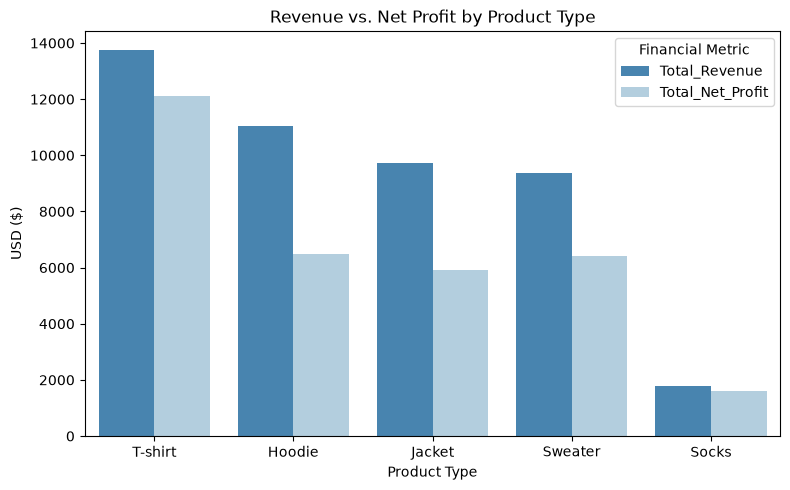

In [79]:
# Combining the two columns for plotting 
df_melted_type = product_type_revenue.melt(
    id_vars='Type', 
    value_vars=['Total_Revenue', 'Total_Net_Profit'], 
    var_name='Financial Metric', 
    value_name='Amount'
)

# Using financial metric as hue to separate the bars in the bar plot
plt.figure(figsize=(8, 5))
sns.barplot(
    data=df_melted_type, 
    x='Type', 
    y='Amount', 
    hue='Financial Metric', 
    palette='Blues_r',
    errorbar=None
)

# Plotting the bar chart with appropriate labels and title
plt.title('Revenue vs. Net Profit by Product Type')
plt.tight_layout()
plt.xlabel('Product Type')
plt.ylabel('USD ($)')
plt.legend(title='Financial Metric', loc='upper right')
plt.show()

#### Total Revenue & Net Profit By Product Type Analysis

* The above graph clearly visualisizes the difference between the total revenue and net profit of items 
* We can see that T shirts were our star performers and socks were the least performers 
* Both T-shirts and socks have a high gorss margin as there is not much difference between the revenue and cost of the products
* However our winter collection products like hoodie, jackets and sweaters have a wider difference between Total revenue and Total Net Profit as it makes sense that these items have a higher cost of goods sold


### Revenue Over The Period From 2019 - 2022

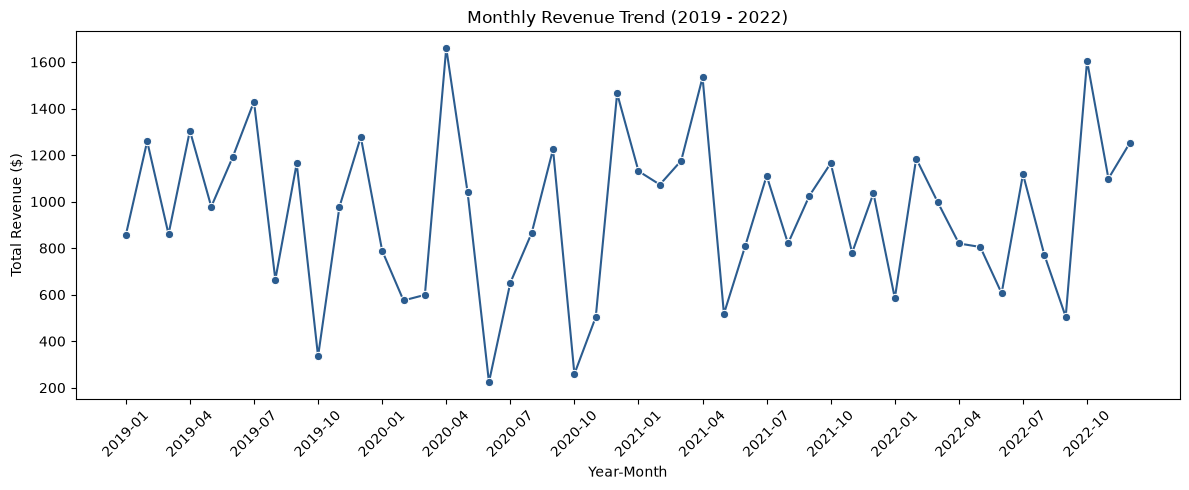

In [80]:
# Aggregate revenue by Year_Month column
monthly_rev = orders_df.groupby('Year_Month')['Total Revenue'].sum().reset_index()
monthly_rev['Year_Month'] = monthly_rev['Year_Month'].astype(str)

# Plotting continuous line chart across the full timeline
plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_rev, x='Year_Month', y='Total Revenue', marker='o', color='#2b5c8f')

plt.title('Monthly Revenue Trend (2019 - 2022)')
plt.xlabel('Year-Month')
plt.ylabel('Total Revenue ($)')

# Display x-ticks for every 3rd month instead of every single month
n = 3
plt.xticks(
    ticks=range(0, len(monthly_rev), n), 
    labels=monthly_rev['Year_Month'].iloc[::n], 
    rotation=45
)

plt.tight_layout()
plt.show()

### Revenue Analysis For The Period 2019 - 2022


* High Sales Seasons: Revenue consistently spikes twice a year, reaching top sales between $1,400 and $1,650. The strongest months are usually April and Octobee
* Low Sales Seasons: Major drops happen immediately after peak months, with revenue falling as low as $200 to $500. Mid-year months like May and June regularly see the sharpest declines.
* Overall Trend: Over the four years, baseline sales have stayed fairly steady overall, though the lowest point in 2021–2022 ($500) was slightly higher than the lowest point in 2020 ($220). The strongest revenue month was April 2020 and the lowest revenue month was also in 2020 during the month of June.

##### Recommendation

* Have mid-yaer promotions and discounts for customers to keep sales steady in the at the least sales months 
* Launch new summer categories and do not only rely on winter categories 

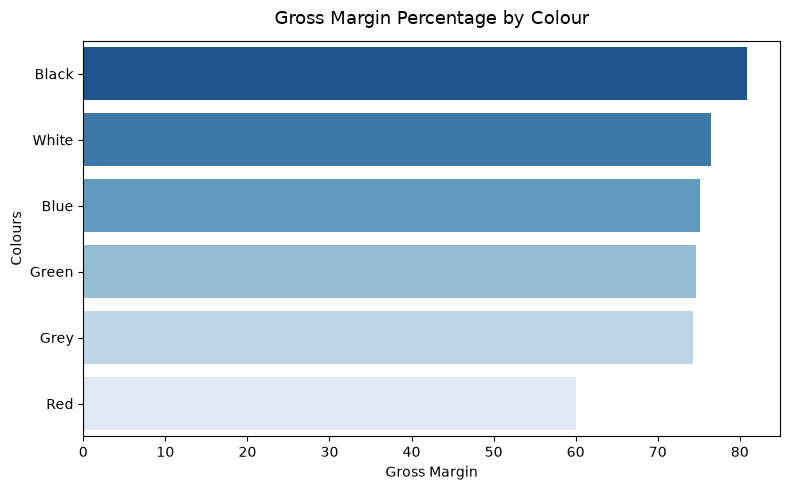

In [81]:
# Plot horizontal bar chart
plt.figure(figsize=(8, 5))
sns.despine()
sns.barplot(
    data=GPM_colours, 
    y='Colour', 
    x='Gross_Margin', 
    hue = 'Colour',
    palette='Blues_r',
    orient='h'
)

plt.title('Gross Margin Percentage by Colour', fontsize=13, pad=12)
plt.xlabel('Gross Margin')
plt.ylabel('Colours')
plt.tight_layout()
plt.show()

In [82]:
GPM_colours

,Colour,Gross_Margin
0,Black,80.855140
1,White,76.479485
2,Blue,75.205976
3,Green,74.607955
4,Grey,74.255263
5,Red,60.000000


### Gross Margin Analysis

* Black colour is our star performer with the highest gross margin of 80%  
* All other colours sta between the range from 74% to 76% 
* However the color red has the least gross margin percentage but still has the lowest revenue generated, the availability, displays at stores needs to be checked and also the kind of designs that we are offering our customers for the red color especially
* Once such market research is done then only can we be in a position to make a decision on what needs to be our next action plan  

### Shipping Method By City 

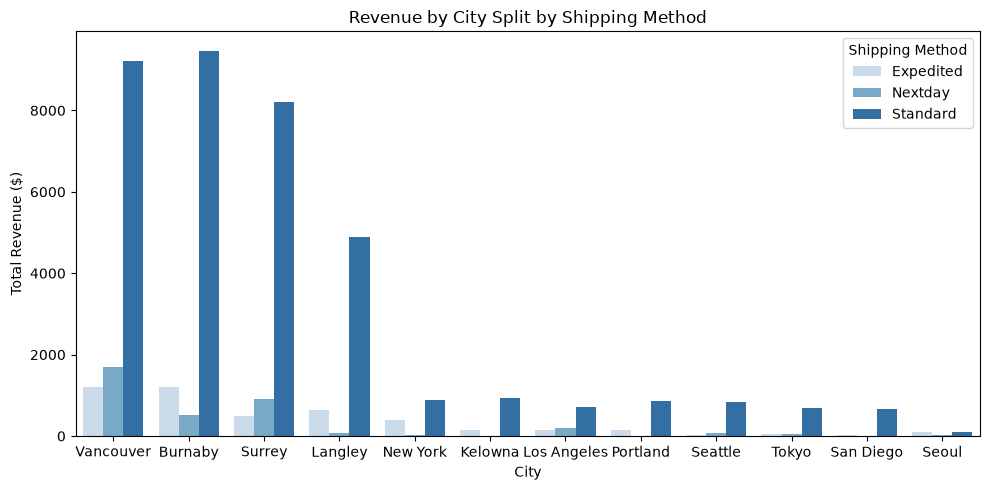

In [83]:
# Aggregate revenue by City and Shipping Method
city_shipping = (
    orders_df.groupby(['City', 'ShippingMethod'])['Total Revenue']
    .sum()
    .reset_index()
)

# Sort cities by total revenue for clean visual ordering
city_order = (
    city_shipping.groupby('City')['Total Revenue']
    .sum()
    .sort_values(ascending=False)
    .index
)

# Plotting Grouped Bar Chart
plt.figure(figsize=(10, 5))
sns.barplot(
    data=city_shipping,
    x='City',
    y='Total Revenue',
    hue='ShippingMethod',
    order=city_order,
    palette='Blues',
    errorbar=None
)

plt.title('Revenue by City Split by Shipping Method')
plt.xlabel('City')
plt.ylabel('Total Revenue ($)')
plt.legend(title='Shipping Method')
plt.tight_layout()
plt.show()

### Shipping Method By City Analysis

* We can clearly see the difference in revenue for the cities which are aligned in decending order. The top 3 cities contribute the highest to the total revenue and Langley is also acceptable 
* However all of the other cities have a really low contribution to total revenue and it is questionable whether the stores are covering their overheads and other expenses or not. 
* Are we working with these stores with a loss? 
* How long can we bare this loss?
* More over most of the revenue comes from the standard shipping method while only a portino of 18% comes from expedited and next day shipping method which is acceptable as not all customers have a sense of urgency. It is a feasible option to give to the customers.

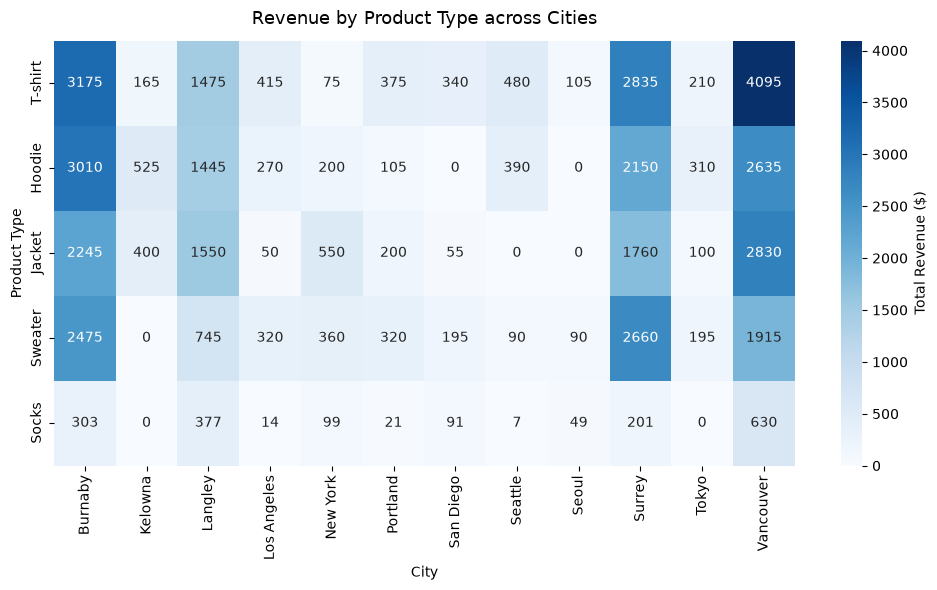

In [84]:
# Plot Seaborn Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    revenue_matrix, 
    annot=True, 
    fmt='.0f', 
    cmap='Blues', 
    cbar_kws={'label': 'Total Revenue ($)'}
)

plt.title('Revenue by Product Type across Cities', fontsize=13, pad=12)
plt.xlabel('City')
plt.ylabel('Product Type')
plt.tight_layout()
plt.show()

### Analysis

* Top Performing Cities: Vancouver, Burnaby, and Surrey generate the vast majority of overall sales. Vancouver records the highest individual product revenue in the dataset with $4,095 in T-shirt sales, followed by Burnaby ($3,175 for T-shirts, $3,010 for Hoodies) and Surrey ($2,835 for T-shirts, $2,660 for Sweaters).
* Top Performing Products: T-shirts generate the highest revenue overall, maintaining solid demand across almost all markets. Hoodies and Jackets follow as strong secondary drivers, whereas Socks remain the lowest-earning category across all locations (peaking at $630 in Vancouver).
* Underperforming & Niche Markets: Low sales volume is concentrated in cities like Seoul, Tokyo, Kelowna, and Los Angeles. Certain categories show zero revenue in specific markets (e.g., $0 for Sweaters/Socks in Kelowna, and $0 for Jackets/Hoodies in Seoul).

#### Strategic Takeaways

* Focus Inventory on Core Hubs: Prioritize stock allocation for high-demand apparel (T-shirts, Hoodies, Jackets) in primary revenue driver cities like Vancouver, Burnaby, and Surrey.
* Review Low-Volume Regions: Re-evaluate marketing spend or inventory presence in underperforming international and secondary markets (e.g., Seoul, Tokyo), or consider localizing product offerings to better fit regional demand.

# **Summary**

### **Top 3 Findings**

1. We only have categories for winters and only a single product type of T-shirts for summers. Socks may be considered for both but our main revenue drivers is T-shirts for summers. 

2. Revenue is highly concentrated in 3 top cities which is 72% and if we take top 4 cities the number increases to 84% which means we need to start focusing on whats not working for the other stores.

3. Strict Single-Item Shopping Behavior: All of the 603 transactions consist of a single item per order (OrderID contains 0 multi-line orders). Traditional market basket and cross-selling analyses are not viable for this dataset, and revenue growth relies entirely on unit pricing and transaction volume rather than increasing items per cart. Our customers are buying only a single item at a time. So Average Order Value (AOV) would be exactly the same as Average Unit Price for products.

### **Actionable Recommendation** 

1. Product Categories: The only avalaible categories are for winter with product types like hoodies, jackets and sweater. We only have T-shirts for summers which is why our sales do drop during the summers as T-shirts would be carrying it. New summer wear categories need to be introduced such as sandos, sleeveless shirts, trousers and shorts. This would give the customers a variety of options to select from even in summers and would boost the sales for the entire business.

2. Extensive Market & Customer Research: The business needs to identify their target market and also have thorough research before launching or opening retail outlets at different cities as our revenue is highly concentrated only in top 3 countries about 72%. Which means we are not giviving what the customer in other cities want. It may be possible beacuse of low brand awareness, sizing issues or customer preferences/trends in the city. We need to keep in mind the preference of customers in those different cities and provide the products accordingly. A thourough market research on customers and provide products accordingly would definitely increase sales in those countries

3. Accessory Bundling & Upselling: Since Socks represent a cross-season product line, consider testing promotional incentives (e.g., "Buy a Hoodie, get Socks at 50% off") to encourage multi-item purchases and shift baseline consumer behavior away from single-item checkouts. This would also encourage customers to go for different product types in a single order.

### **Data Quality Decisions**

* Rows lost to joins were 51 records which were all connected to only one city of Conquitlam. These made about 7.8% of the total records.
* Similarly all transactions related to Conquitlam were also lost which were around 7.72% as well.
* In total we did not include Conquitlam in our analysis. As we are looking at the cities and stores seperatly at most analysis levels, the totality results may be changed but drilled down levels would remain the same 
* We removed 7 duplicate records from the dataset which is about 1.06% of the transactions data set. I checked them by calling them out the entire rows at those indexes have the exact same values, same product, order ID, date etc
* Only 4 missing vlaues were filled with expedited which in my opinion should not have been the case, we should have asked about the shipping method of each of the cities before proceeding to fill them with expedited

### **What Can Not Be Answered By The Dataset** 

* Customer Life Time Value can not be calculated as no data for customers is avalaible
* Customer Retention analysis can not be done as no data for customers is avalaible
* Customer Average Order Value can not be calulated as no data for customers is avalaible
* Stock shortages and excess can not be analysed as no inventory data is available 
* No inventory data means no ratios regarding stocks can be calculated such as sell through rate, net days inventory, stock to sales ratios, aging for inventory, identifying dead stock, stock to sales contribution. Also no interstore transfer can be done to fulfill shoratges from other stores and better management of inventory like providing the stores with ample of product type that they sell the most 
* No campaign data is present apart from the 30% discount on socks and so calculated the return on investment from marketing activities is not possible 
* Root cause analysis for low performing cities can not be established from this data set as no research on customers and market preferences is done here

# **THANK YOU**